In [89]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from helpers.input_shapes import input_shape, real_input_shape

In [3]:
# ---------
# Constants
# ---------

# Clebsch-Gorden coefficient D2 line (F2 -> F'3)
Mu0 = -np.sqrt(1 / 6)  # pi (mf2 -> mf2)
Mu1 = -np.sqrt(3 / 10)  # pi (mf0 -> mf0)

G0_kc = 2 * np.pi * 0.0438  # coupling strength (F2mf2 -> F'3mf2)
G_pi_KC = G0_kc * (Mu1 / Mu0)  # coupling strength (F2mf0 -> F'3mf0)

Kappa = 2 * np.pi * 0.063  # cavity dissipation rate
Kappa_oc = 2 * np.pi * 0.054
Gamma_5P32_5S = 2 * np.pi * 0.006065 / 2  # atom dissipation rate

Mu_rf = 1
Mu_fc = 0.9

tlist = np.linspace(0, 5000, 10000, dtype=np.float32)
args = {"t0": 1000, "tau": 70.0, "tau_start": 91.0, "sigma": 1.0}


a = [2, 2]  # Cavity modes: One for pi and one for V
b = [2, 2]  # External Light modes: Same logic here
# 2 because then the states will be |0> or |1>, which would be the cases for either having 0 or 1 photon in your cavity or light field

N_env = 1  # Number of frequency bins

In [4]:
a_pi = qt.destroy(a[0])
a_v = qt.destroy(a[1])

b_pi = [qt.destroy(b[0]) for _ in range(N_env)]
b_v = [qt.destroy(b[1]) for _ in range(N_env)]

photonic_dimensions = (
    a + b * N_env
)  # List with dimensions for each photon mode both in cavity and externally

photon_id = qt.tensor([qt.qeye(dim) for dim in photonic_dimensions])

In [5]:
Atom_dimensions = 5  # |F=1,m_f=0>,|F=2,m_f=0>,|F=2,m_f=-1>,|F=2,m_f=+1>,|F'=3,m_f=0>
atom_id = qt.qeye(Atom_dimensions)

atom_kets = [qt.basis(Atom_dimensions, i) for i in range(Atom_dimensions)]

In [92]:
def calc_transition_op(m_idx: int, n_idx):
    return atom_kets[m_idx] * atom_kets[n_idx].dag()


transition_ops = {}
for m in range(Atom_dimensions):
    for n in range(Atom_dimensions):
        transition_ops[(m, n)] = qt.tensor(calc_transition_op(m, n), photon_id)

dimension_tot = [Atom_dimensions] + photonic_dimensions

In [93]:
def embed_photons(op_list):
    """Place op_list[i] into slot i, None -> identity of that slot."""
    op = qt.tensor(
        [
            op if op is not None else qt.qeye(d)
            for op, d in zip(op_list, photonic_dimensions)
        ]
    )
    full_op = qt.tensor(atom_id, op)
    return full_op

In [103]:
a_pi_embedded = embed_photons([a_pi, None] + [None] * N_env + [None] * N_env)
a_v_embedded = embed_photons([a_pi, None] + [None] * N_env + [None] * N_env)

b_pi_embedded = [
    embed_photons(
        [None, None]
        + [b_pi[i] if k == i else None for k in range(N_env)]
        + [None] * N_env
    )
    for i in range(N_env)
]
b_v_embedded = [
    embed_photons(
        [None, None]
        + [b_v[i] if k == i else None for k in range(N_env)]
        + [None] * N_env
    )
    for i in range(N_env)
]

In [104]:
H_couple = []

for i in range(N_env):
    H_couple.append(
        1j
        * np.sqrt(Kappa_oc / 2 * np.pi)
        * (
            a_pi_embedded.dag() * b_pi_embedded[i]
            - a_pi_embedded * b_pi_embedded[i].dag()
        )
    )
    H_couple.append(
        1j
        * np.sqrt(Kappa_oc / 2 * np.pi)
        * (a_v_embedded.dag() * b_v_embedded[i] - a_v_embedded * b_v_embedded[i].dag())
    )

In [105]:
H_int = G_pi_KC * (
    transition_ops[(1, 4)] * a_pi_embedded.dag()
    + transition_ops[(4, 1)] * a_pi_embedded
)

In [106]:
H_drive = np.sqrt(2 * Kappa_oc) * (b_pi_embedded[0] + b_pi_embedded[0].dag())

In [115]:
photon_initial_state = [qt.basis(dim, 0) for dim in photonic_dimensions]
atom_initial_state = qt.basis(Atom_dimensions, 0)
full_initial_state = qt.tensor([atom_initial_state] + photon_initial_state)

In [108]:
H = [H_int] + H_couple + [[H_drive, input_shape]]

In [109]:
c_obs = [
    np.sqrt(2 * Kappa) * a_pi_embedded,
    np.sqrt(2 * Kappa) * a_v_embedded,
    #np.sqrt(2 * Gamma_5P32_5S * 1 / 10)
    #* transition_ops[(2, 4)],  # |F=2,m_f=-1><F'=3,m_f=0|
    #np.sqrt(2 * Gamma_5P32_5S * 1 / 10)
    #* transition_ops[(3, 4)],  # |F=2,m_f=+1><F'=3,m_f=0|
]

In [110]:
e_obs = [transition_ops[(0, 0)], 
         transition_ops[(1, 1)],
         transition_ops[(4, 4)],
         a_pi_embedded,
         a_v_embedded,
         b_pi_embedded[0],
         b_v_embedded[0],
         ]

In [116]:
result = qt.mesolve(
    H,
    full_initial_state,
    tlist,
    c_obs,
    e_obs,
    args,
    options=qt.Options(store_states=True, progress_bar="enhanced"),
)

 Total run time: 452.09s*] Elapsed 452.09s / Remaining 00:00:00:00


In [117]:
qt.fileio.qsave(result, "sim_results/atom_in_0_b_pi_drive_no_atom_decay")

In [118]:
result = qt.fileio.qload("sim_results/atom_in_0_b_pi_drive_no_atom_decay")

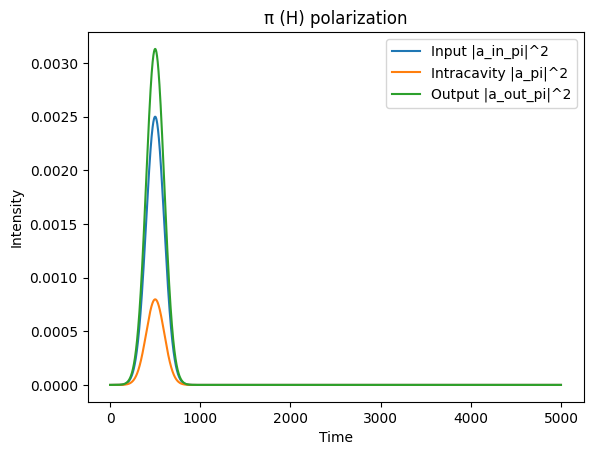

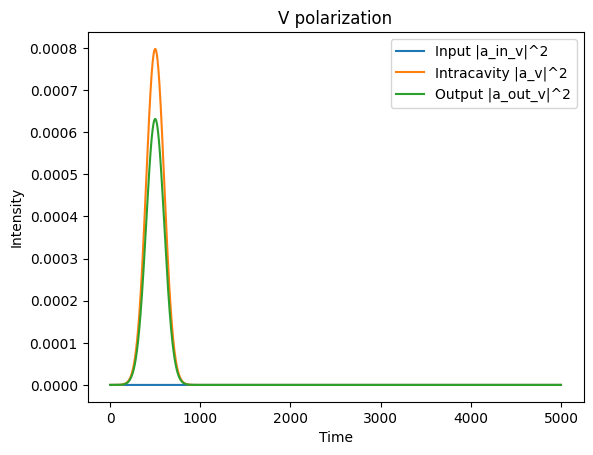

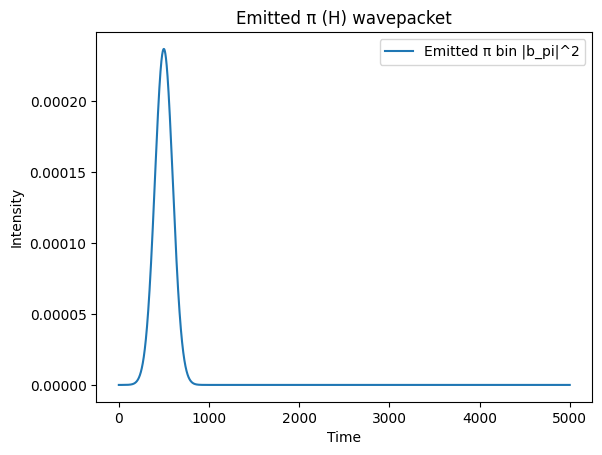

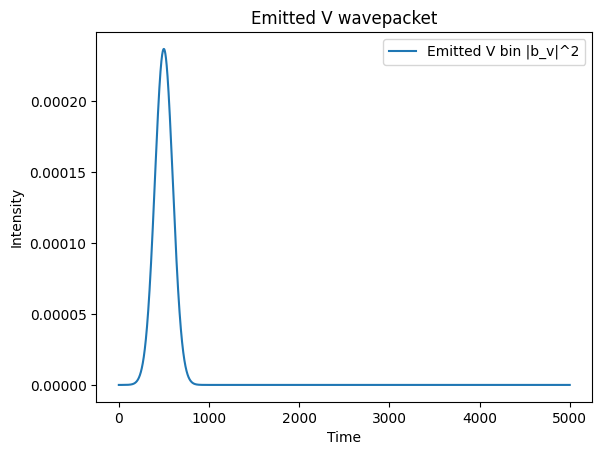

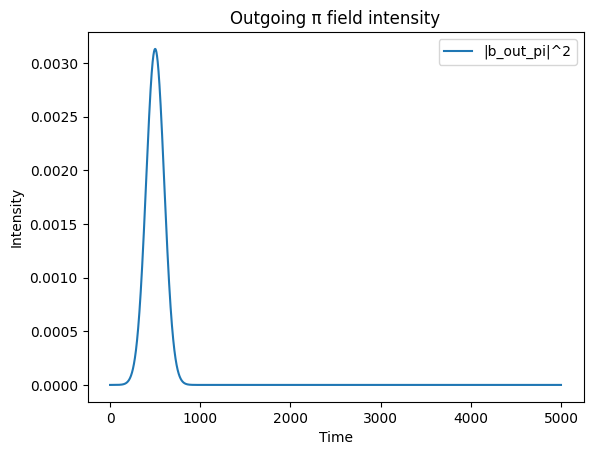

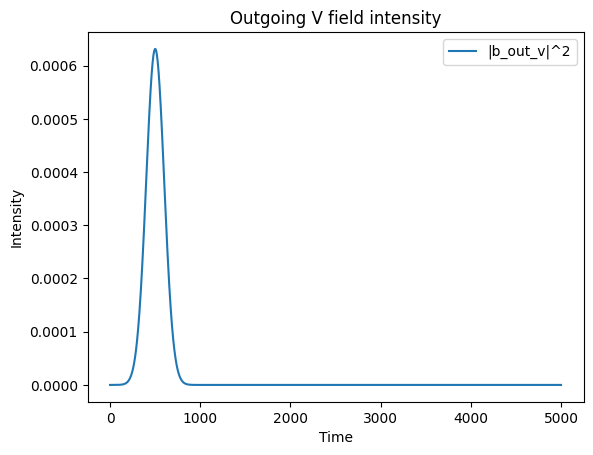

In [125]:
# --- Extract results ---
pop_0 = result.expect[0]  # |0>
pop_1 = result.expect[1]  # |1>
pop_e = result.expect[2]  # |e>

a_pi_vals = np.array(result.expect[3])   # <a_pi>
a_v_vals  = np.array(result.expect[4])   # <a_v>

b_pi_vals = np.array(result.expect[5])   # <b_pi> bin 0
b_v_vals  = np.array(result.expect[6])   # <b_v> bin 0

# --- Input fields ---
a_in_pi = np.array([input_shape(t, args) for t in tlist])
a_in_v  = np.zeros_like(a_in_pi)   # no v-polarized input

# --- Output fields via input-output ---
a_out_pi = a_in_pi - np.sqrt(2*Kappa) * a_pi_vals
a_out_v  = a_in_v  - np.sqrt(2*Kappa) * a_v_vals

# --- Intensities ---
input_pi_intensity   = np.abs(a_in_pi)**2
cavity_pi_intensity  = np.abs(a_pi_vals)**2
output_pi_intensity  = np.abs(a_out_pi)**2

input_v_intensity   = np.abs(a_in_v)**2
cavity_v_intensity  = np.abs(a_v_vals)**2
output_v_intensity  = np.abs(a_out_v)**2

emitted_pi_intensity = np.abs(b_pi_vals)**2
emitted_v_intensity  = np.abs(b_v_vals)**2

a_in_pi = np.array([input_shape(t, args) for t in tlist])
a_pi_vals = np.array(result.expect[3])   # <a_pi>
b_out_pi = a_in_pi - np.sqrt(2*Kappa) * a_pi_vals

a_in_v = np.zeros_like(a_in_pi)
a_v_vals = np.array(result.expect[4])
b_out_v = a_in_v - np.sqrt(2*Kappa) * a_v_vals

# Intensities
b_out_pi_intensity = np.abs(b_out_pi)**2
b_out_v_intensity  = np.abs(b_out_v)**2


# --- Plots ---
plt.figure()
plt.plot(tlist, input_pi_intensity, label="Input |a_in_pi|^2")
plt.plot(tlist, cavity_pi_intensity, label="Intracavity |a_pi|^2")
plt.plot(tlist, output_pi_intensity, label="Output |a_out_pi|^2")
#plt.plot(tlist, input_shape(tlist,args), label="input shape", c="gray")
plt.title("π (H) polarization")
plt.legend(); plt.xlabel("Time"); plt.ylabel("Intensity")

plt.figure()
plt.plot(tlist, input_v_intensity, label="Input |a_in_v|^2")
plt.plot(tlist, cavity_v_intensity, label="Intracavity |a_v|^2")
plt.plot(tlist, output_v_intensity, label="Output |a_out_v|^2")
#plt.plot(tlist, input_shape(tlist,args), label="input shape", c="gray")
plt.title("V polarization")
plt.legend(); plt.xlabel("Time"); plt.ylabel("Intensity")

plt.figure()
plt.plot(tlist, emitted_pi_intensity, label="Emitted π bin |b_pi|^2")
#plt.plot(tlist, input_shape(tlist,args), label="input shape", c="gray")
plt.title("Emitted π (H) wavepacket")
plt.legend(); plt.xlabel("Time"); plt.ylabel("Intensity")

plt.figure()
plt.plot(tlist, emitted_v_intensity, label="Emitted V bin |b_v|^2")
#plt.plot(tlist, input_shape(tlist,args), label="input shape", c="gray")
plt.title("Emitted V wavepacket")
plt.legend(); plt.xlabel("Time"); plt.ylabel("Intensity")

plt.figure()
plt.plot(tlist, b_out_pi_intensity, label="|b_out_pi|^2")
plt.title("Outgoing π field intensity")
plt.xlabel("Time"); plt.ylabel("Intensity"); plt.legend()

plt.figure()
plt.plot(tlist, b_out_v_intensity, label="|b_out_v|^2")
plt.title("Outgoing V field intensity")
plt.xlabel("Time"); plt.ylabel("Intensity"); plt.legend()

plt.show()


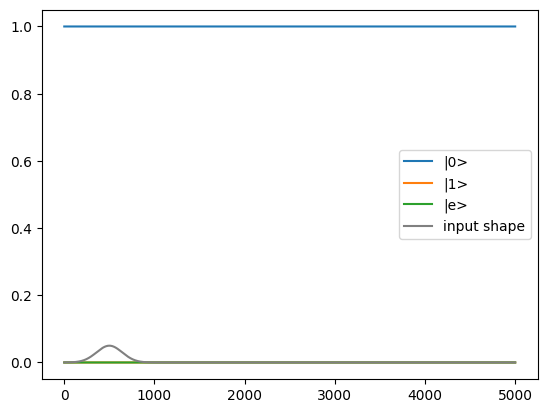

In [122]:
plt.plot(tlist, pop_0, label="|0>")
plt.plot(tlist, pop_1, label="|1>")
plt.plot(tlist, pop_e, label="|e>")
plt.plot(tlist, input_shape(tlist,args), label="input shape", c="gray")
plt.legend()
plt.show()